In [3]:
from zipfile import ZipFile

with ZipFile("creditcard.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

In [4]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

First 5 Rows
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

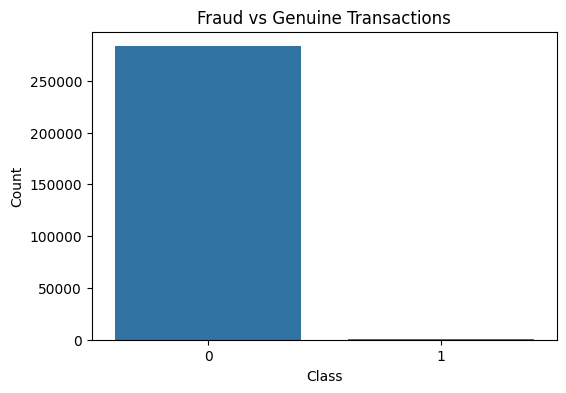

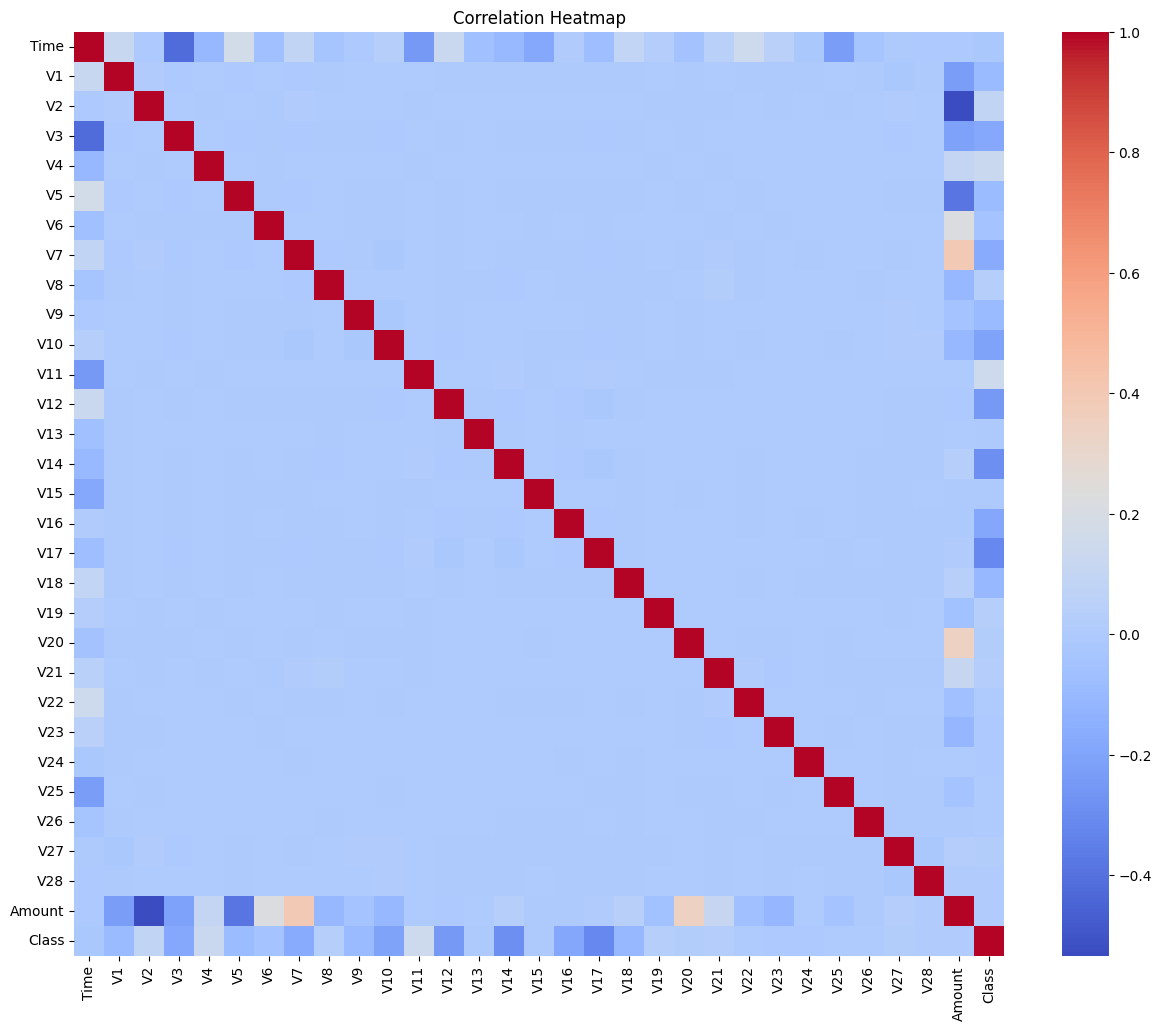

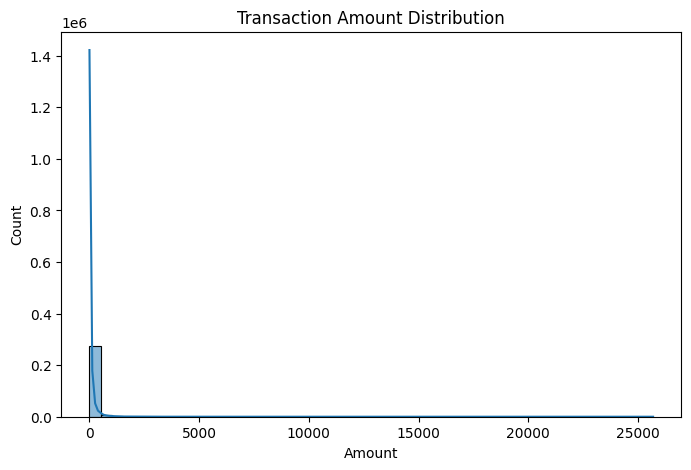

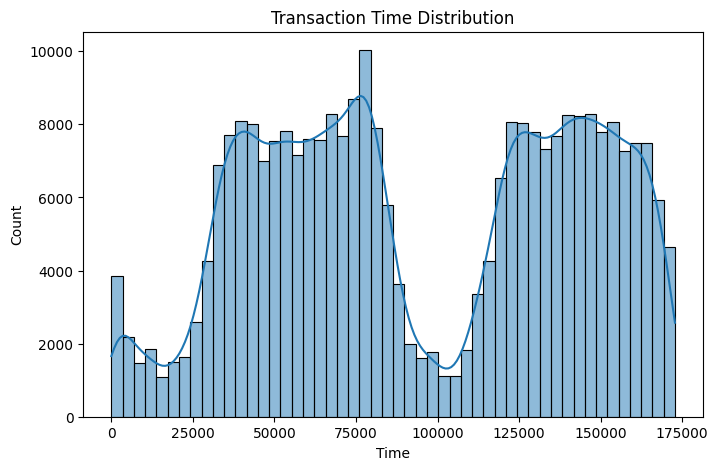

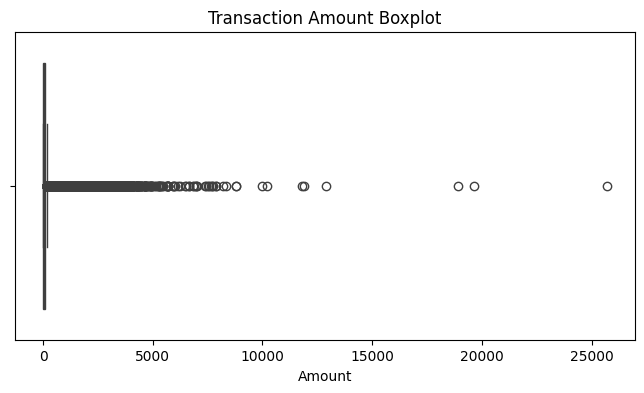


Features Shape : (283726, 30)
Target Shape : (283726,)

Training Data
(226980, 30)
(226980,)

Testing Data
(56746, 30)
(56746,)

Feature Scaling Completed Successfully!


In [5]:
# ==========================================
# PROJECT 2 - FRAUD DETECTION PIPELINE
# PART 1
# ==========================================

# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv("creditcard.csv")

print("First 5 Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ------------------------------------------
# Check Missing Values
# ------------------------------------------

print("\nMissing Values")
print(df.isnull().sum())

# ------------------------------------------
# Check Duplicate Rows
# ------------------------------------------

duplicates = df.duplicated().sum()

print("\nDuplicate Rows :", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates Removed Successfully!")

# ------------------------------------------
# Check Fraud Distribution
# ------------------------------------------

print("\nFraud Class Distribution")

print(df["Class"].value_counts())

print("\nFraud Percentage")

print(df["Class"].value_counts(normalize=True)*100)

# ------------------------------------------
# Count Plot
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Genuine Transactions")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

# ------------------------------------------
# Correlation Heatmap
# ------------------------------------------

plt.figure(figsize=(15,12))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# ------------------------------------------
# Distribution of Transaction Amount
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50, kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

# ------------------------------------------
# Distribution of Time
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df["Time"], bins=50, kde=True)

plt.title("Transaction Time Distribution")

plt.show()

# ------------------------------------------
# Boxplot for Amount
# ------------------------------------------

plt.figure(figsize=(8,4))

sns.boxplot(x=df["Amount"])

plt.title("Transaction Amount Boxplot")

plt.show()

# ------------------------------------------
# Feature Matrix and Target
# ------------------------------------------

X = df.drop("Class", axis=1)

y = df["Class"]

print("\nFeatures Shape :", X.shape)

print("Target Shape :", y.shape)

# ------------------------------------------
# Train Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("\nTraining Data")

print(X_train.shape)

print(y_train.shape)

print("\nTesting Data")

print(X_test.shape)

print(y_test.shape)

# ------------------------------------------
# Feature Scaling
# ------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("\nFeature Scaling Completed Successfully!")

Original Training Dataset
Class
0    226602
1       378
Name: count, dtype: int64

After Applying SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64

Logistic Regression Model Trained Successfully!

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

Precision : 0.053035143769968054
Recall : 0.8736842105263158
F1 Score : 0.1
ROC AUC : 0.9626184886409772

Confusion Matrix
[[55169  1482]
 [   12    83]]


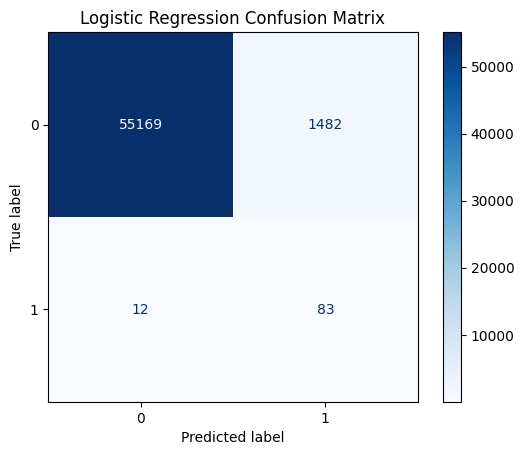

In [6]:
# ==========================================
# PART 2 - SMOTE + LOGISTIC REGRESSION
# ==========================================

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# ------------------------------------------
# Apply SMOTE
# ------------------------------------------

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Dataset")

print(y_train.value_counts())

print("\nAfter Applying SMOTE")

print(pd.Series(y_train_smote).value_counts())

# ------------------------------------------
# Train Logistic Regression
# ------------------------------------------

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_smote, y_train_smote)

print("\nLogistic Regression Model Trained Successfully!")

# ------------------------------------------
# Prediction
# ------------------------------------------

y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

# ------------------------------------------
# Evaluation
# ------------------------------------------

print("\nClassification Report")

print(classification_report(y_test, y_pred_log))

print("Precision :", precision_score(y_test, y_pred_log))

print("Recall :", recall_score(y_test, y_pred_log))

print("F1 Score :", f1_score(y_test, y_pred_log))

print("ROC AUC :", roc_auc_score(y_test, y_prob_log))

# ------------------------------------------
# Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(y_test, y_pred_log)

print("\nConfusion Matrix")

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

Random Forest Model Trained Successfully!

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Precision : 0.9125
Recall : 0.7684210526315789
F1 Score : 0.8342857142857143
ROC AUC : 0.9694220104815354

Confusion Matrix
[[56644     7]
 [   22    73]]


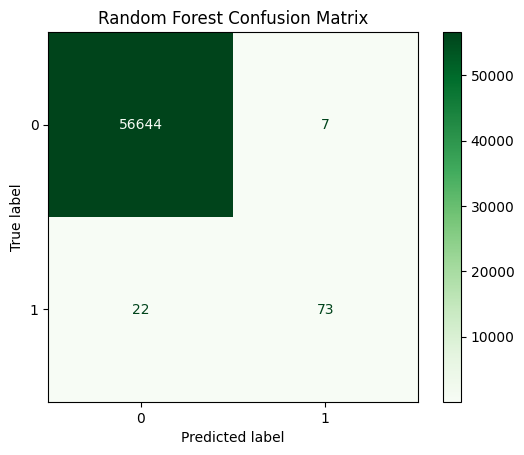

In [8]:
# ==========================================
# PART 3 - RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# ------------------------------------------
# Train Random Forest
# ------------------------------------------

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest Model Trained Successfully!")

# ------------------------------------------
# Prediction
# ------------------------------------------

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ------------------------------------------
# Evaluation
# ------------------------------------------

print("\nClassification Report")

print(classification_report(y_test, y_pred_rf))

print("Precision :", precision_score(y_test, y_pred_rf))

print("Recall :", recall_score(y_test, y_pred_rf))

print("F1 Score :", f1_score(y_test, y_pred_rf))

print("ROC AUC :", roc_auc_score(y_test, y_prob_rf))

# ------------------------------------------
# Confusion Matrix
# ------------------------------------------

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix")

print(cm_rf)

ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [11]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(comparison)

                 Model  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression   0.053035  0.873684  0.100000  0.962618
1        Random Forest   0.912500  0.768421  0.834286  0.969422


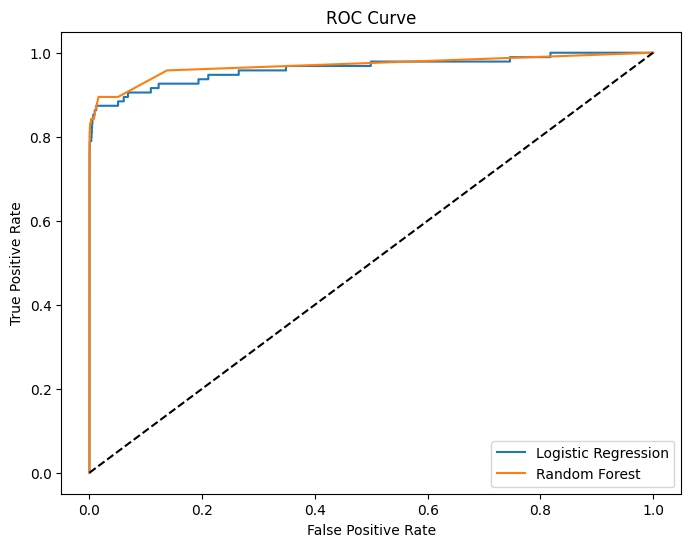

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [13]:
import joblib

joblib.dump(rf_model, "Fraud_Detection_Model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [14]:
comparison.to_csv("Model_Comparison.csv", index=False)

print("Comparison Saved Successfully!")

Comparison Saved Successfully!
